# Capítulo 8 - Gradiente Descendente

Página 142-155

## A Ideia Central do Gradiente Descendente

O gradiente é o vetor das derivadas parciais. Em cada ponto, ele aponta a direção em que a função cresce mais rápido.

$$ \nabla f(x,y) = \left( \frac{\partial{f}}{\partial{x}},\frac{\partial{f}}{\partial{y}} \right) $$

Ele é a ferramenta que nos permite **otimizar** uma função, ou seja, encontrar a entrada que a torna a maior ou menor possível. Para isso, utilizamos o algoritmo:

1. selecinar um ponto de partida aleatório
2. computar o gradiente nesse ponto
3. dar um pequeno passo:
  - na **direção do gradiente** (direção que a função cresce mais), se quiser **maximizar** uma função (gradiente ascendente)
  - na **direção oposta do gradiente**, se quiser **minimizar** uma função (gradiente descendente)
4. repetir o procedimento com o novo ponto de partida.

Seguindo esses passos, se a função tem um mínimo global, certamente a encontraremos. Mas se a função tiver vários mínimos, podemos encontrar o "errado", então nesse caso executamos os passos várias vezes, partindo de diferentes pontos de partida. E se a função não tiver um mínimo, o procedimento pode ficar em um loop infinito.

## Estimando o Gradiente

### Função de uma variável

In [10]:
# estimativa da definicao da derivada para uma funcao de uma variavel
# limite do quociente das diferencas -> quando h se aproxima de zero
from typing import Callable

def difference_quotient(f: Callable[[float], float],
                        x: float,
                        h: float) -> float:
  return (f(x + h) - f(x)) / h

In [11]:
# exemplo de funcao com uma variavel
def square(x: float) -> float:
    return x * x

# e sua derivada exata
def derivatrive_of_square(x: float) -> float:
    return 2 * x

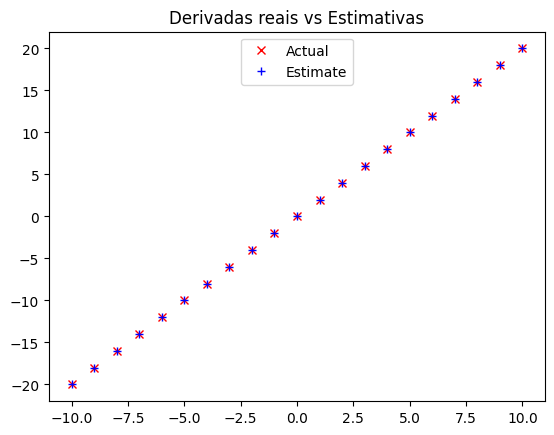

In [12]:
# compara derivada real com estimativa
import matplotlib.pyplot as plt

xs        = range(-10, 11)
actuals   = [derivatrive_of_square(x) for x in xs]                # computa o valor da função derivada
estimates = [difference_quotient(square, x, h=0.001) for x in xs] # computa quociente das diferencas

plt.plot(xs, actuals, 'rx', label='Actual')
plt.plot(xs, estimates, 'b+', label='Estimate')
plt.title("Derivadas reais vs Estimativas")
plt.legend(loc=9)
plt.show()

### Função com mais de uma variável

In [13]:
# derivada parcial
def partial_difference_quotient(f: Callable[[list], float],
                                 v: list,
                                 i: int,
                                 h: float) -> float:
  """Retorna o quociente parcial das diferencas i de f em v"""
  w = [v_j + (h if j == i else 0) for j, v_j in enumerate(v)] # adiciona h somente ao elemento i de v

  return (f(w) - f(v)) / h


# estimativa do gradiente
def estimate_gradient(f: Callable[[list], float],
                      v: list,
                      h: float = 0.0001):
    return [partial_difference_quotient(f, v, i, h) for i in range(len(v))]

Essa abordagem tem um problema: o custo computacional. Se `v` tem um comprimento _n_, `estimate_gradient` avalia `f` em _2n_ entradas. Por isso é mais vantajoso utilizar o gradiente analítico ou diferenciação automática.

Outro problema ainda não mencionado é _trade-off_ do tamanho de `h`: se for muito pequeno podemos ter problemas devido ao arredondamento de ponto flutuante, e se for muito grande teremos uma aproximação ruim.

## Usando o Gradiente

Vamos usar o gradiente para encontrar o mínimo entre os vetores tridimensionais da função `sum_of_squares`. Selecionaremos um ponto de partida aleatório e daremos pequenos passos na direção oposta do do gradiente, até atingir um ponto em que ele seja muito pequeno:

In [14]:
from modulo_python_livro import distance, vector_add, scalar_multiply
import random

def gradient_step(v: list,
                  gradient: list,
                  step_size: float) -> list:
    """Move `step_size` na direcao de `gradient` a partir de `v`"""

    assert len(v) == len(gradient)
    step = scalar_multiply(step_size, gradient)

    return vector_add(v, step)

# como sabemos que a derivada de x^2 eh 2*x, ja substituimos na funcao
def sum_of_squares_gradient(v: list) -> list:
    return [2 * v_i for v_i in v]

# seleciona um ponto de partida aleatorio
v = [random.uniform(-10, 10) for i in range(3)]


for epoch in range(1000):

    # computa o gradiente em v
    grad = sum_of_squares_gradient(v)

    # da um passo na direcao oposta (sinal negativo)
    v    = gradient_step(v, grad, -0.01)

    if epoch % 100 == 0:
        print(epoch, v)

print(epoch, v)

assert distance(v, [0, 0, 0]) < 0.001

0 [9.567305674451331, -2.080895662377366, -3.7722793241702055]
100 [1.2688118296550872, -0.27596745860780447, -0.5002780086824122]
200 [0.16826926136286682, -0.03659868180197075, -0.06634664733537299]
300 [0.02231579471268154, -0.004853700926910747, -0.008798862904722976]
400 [0.0029595107842343075, -0.0006436956613728551, -0.0011669012908031794]
500 [0.0003924890058708869, -8.536663274264743e-05, -0.0001547539309593319]
600 [5.205171765217019e-05, -1.1321284922560394e-05, -2.0523397596793884e-05]
700 [6.903075678589896e-06, -1.5014237785879239e-06, -2.7218038747382513e-06]
800 [9.154828308024638e-07, -1.9911815472615287e-07, -3.609644211004053e-07]
900 [1.214109264502942e-07, -2.640696125036515e-08, -4.787094122014242e-08]
999 [1.6430064435314855e-08, -3.573550483217738e-09, -6.478186698856246e-09]


## Usando o Gradiente Descendente para ajustar modelos

Agora vamos usar o gradiente descendente para **ajustar os parâmetros de um modelo aos dados**. Nesse caso temos:

- os dados;
- os parâmetros do modelo; e
- uma função de perda que mede a adequação do modelo aos dados, ou seja, o quanto o modelo erra nos dados.

Ao estabelecermos que os dados são fixos, então a função de perda vai indicar a eficácia dos parâmetros do modelo. Assim, podemos usar o gradiente descendente para minimizar ao máximo a perda e definir os parâmetros do modelo.

O modelo é uma equação de reta: $y = 20x + 5$, e portanto os dados são:

In [15]:
# x vai de -50 a 49, y eh sempre 20*x+5
inputs = [(x, 20 * x + 5) for x in range(-50, 50)]
inputs[:3]+inputs[-3:]

[(-50, -995), (-49, -975), (-48, -955), (47, 945), (48, 965), (49, 985)]

Conhecemos os parâmetros da relação linear entre $x$ e $y$, `theta = (20, 5)`, mas vamos tentar obtê-los a partir dos dados. Vamos usar o gradiente descendente para encontrar a inclinação e o intercepto que minimizam o erro quadrático médio (função de perda).

Começamos determinando o gradiente da função de perda com base no erro de apenas um ponto $(x,y)$ dos dados. O erro quadrático médio, que é a função de perda, é o quadrado do "erro entre as predições do modelo e os dados reais", denotado por $\text{error}$. Ou seja, é uma função em termos do erro:

$$ \text{perda} = \text{error}^2 = f(\text{error})$$

Este erro por sua vez, é uma função em termos dos parâmetros $\theta = (\text{slope}, \text{intercept})$ do modelo:

$$ \text{error} = g(\theta) = \text{slope} \space x + \text{intercept} - y $$

Então nesse caso, a função de perda é uma função composta:

$$ \text{perda} = f(g(\theta))$$

O gradiente da função de perda, calculado de modo a encontrar os parâmetros do modelo que a minimizem é:

$$ \nabla \text{perda} = \frac{\partial \text{perda}}{\partial \theta}$$

Aqui devemos nos lembrar da "Regra da Cadeia" para diferenciar funções compostas:

$$ \frac{\partial f(g(\theta))}{\partial \theta} = \frac{\partial f}{\partial g} \frac{\partial g}{\partial \theta} $$

Então o gradiente da função de perda fica:

$$ \frac{\partial(\text{error}^2)}{\partial \theta} = \frac{\partial(\text{error}^2)}{\partial \text{error}} \frac{\partial \text{error}}{\partial \theta} $$

Separando as componentes temos:

$$ \frac{\partial(\text{error}^2)}{\partial \theta} = \left( \frac{\partial(\text{error}^2)}{\partial \text{error}} \frac{\partial \text{error}}{\partial \text{slope}} , \frac{\partial(\text{error}^2)}{\partial \text{error}} \frac{\partial \text{error}}{\partial \text{intercept}} \right) $$

Resolvendo cada uma das derivadas:

$$ \frac{\partial(\text{error}^2)}{\partial \text{error}} = 2\text{error} $$
$$ \frac{\partial \text{error}}{\partial \text{slope}} = x$$
$$ \frac{\partial \text{error}}{\partial \text{intercept}} = 1 $$

E por fim temos:

$$ \frac{\partial(\text{error}^2)}{\partial \theta} = \left( 2\text{error} \space x , 2\text{error} \right) $$

Agora implementamos a função Python que determina o gradiente com base no **erro de apenas um ponto $(x,y)$ dos dados**:

In [16]:
# gradiente da funcao de perda para um ponto (x, y)
def linear_gradient(x: float, y: float, theta: list) -> list:
    slope, intercept = theta
    predicted        = slope * x + intercept      # predicao, o que o modelo previu
    error            = (predicted - y)            # erro, diferenca entre o que o modelo previu e o dado real
    squared_error    = error ** 2                 # erro ao quadrado, funcao de perda a ser minimizada
    grad             = [2 * error * x, 2 * error] # gradiente da  funcao de perda

    return grad

Mas a função de perda que queremos minimizar é o erro quadrático médio em **todos os pontos** do conjunto. Como a derivada de uma média é a média das derivadas, então podemos apenas tirar a média dos gradientes de cada um dos pontos:

In [18]:
# gradiente da funcao de perda em todos os pontos
import random
from modulo_python_livro import vector_mean

# comeca e valores aleatorios para inclinacao (slope) e intercepto (intercept)
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

# step size para a proxima atualizacao
learning_rate = 0.001

for epoch in range(5000):

    # computa o gradiente a partir dos dados e do modelo atual
    grad  = vector_mean([linear_gradient(x, y, theta) for x, y in inputs])

    # atualiza o modelo
    theta = gradient_step(theta, grad, -learning_rate)

    if epoch % 500 == 0:
        print(epoch, theta)

print(epoch, theta)
slope, intercept = theta
assert 19.9 < slope < 20.1,   "slope should be about 20"
assert 4.9 < intercept < 5.1, "intercept should be about 5"

0 [33.745045840353896, 0.2815991923627931]
500 [19.998960029313317, 3.268448182066778]
1000 [19.999617684045628, 4.36344370635414]
1500 [19.999859452299148, 4.765987993669284]
2000 [19.99994833159331, 4.913972071828429]
2500 [19.99998100556442, 4.968374253349063]
3000 [19.999993017230327, 4.988373684308252]
3500 [19.999997432981253, 4.995725912243081]
4000 [19.999999056307804, 4.998428751924673]
4500 [19.99999965307812, 4.9994223748657864]
4999 [19.999999872208427, 4.9997872269576]


In [19]:
theta

[19.999999872208427, 4.9997872269576]

In [20]:
# usa quociente diferencial para conferir se a derivada esta certa
def squared_error_loss(theta, x=2, y=45):
    slope, intercept = theta
    return (slope * x + intercept - y) ** 2

def partial_difference_quotient(f, v, i, h):
    w = [v_j + (h if j == i else 0) for j, v_j in enumerate(v)]
    return (f(w) - f(v)) / h

def estimate_gradient(f, v, h=0.00001):
    return [partial_difference_quotient(f, v, i, h) for i in range(len(v))]

theta = [random.uniform(-1, 1), random.uniform(-1, 1)]
print(estimate_gradient(squared_error_loss, theta))  # ≈ [-180, -90]
print(linear_gradient(2, 45, theta))                 # [-180.0, -90.0]

[-178.0818770157566, -89.04094854642607]
[-178.08191702595371, -89.04095851297686]


## Minibatch e Gradiente Descendente Estocástico

Nessa técnica damos o passo de atualização com base na avaliação feita em uma amostra da base, eliminando a necessidade de avaliar o gradiente em todos os dados do conjunto.

In [21]:
from typing import TypeVar, List, Iterator

T = TypeVar('T') # permite a insercao de funcoes generica

def minibatches(dataset: list[T],
                batch_size: int,
                shuffle: bool = True) -> Iterator[list[T]]:
    """Gera minibatches de tamanho `batch_size` a partir do conjunto de dados"""

    batch_starts = [start for start in range(0, len(dataset), batch_size)]

    if shuffle:
        # embaralha os dados
        random.shuffle(batch_starts)

    for start in batch_starts:
        end = start + batch_size
        yield dataset[start:end]

In [22]:
# resolvemos o mesmo problema usando minibatchs
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(1000):

    for batch in minibatches(inputs, batch_size=20):
        grad  = vector_mean([linear_gradient(x, y, theta) for x, y in batch])
        theta = gradient_step(theta, grad, -learning_rate)

    if epoch % 100 == 0:
        print(epoch, theta)

print(epoch, theta)
slope, intercept = theta
assert 19.9 < slope < 20.1,   "slope should be about 20"
assert 4.9 < intercept < 5.1, "intercept should be about 5"

0 [18.222917160809452, -2.841492933106184]
100 [20.40123164267108, 4.05413497667965]
200 [19.976616355453082, 4.7551070042073915]
300 [20.015444660735582, 4.964398053894177]
400 [19.999986720148623, 4.995249484022238]
500 [20.000010506734892, 4.999002487369888]
600 [19.999843236945903, 4.999637870375618]
700 [19.999993860216488, 4.999893226418235]
800 [20.00000960804652, 4.999977700937661]
900 [20.000000082265913, 4.99999670404312]
999 [19.999999512023305, 4.99999879853379]


Outra variação é o gradiente descendente estocástico, que dá os passos de atualização para o próximo gradiente com base em um ponto de cada vez. Abaixo sua implementação:

In [23]:
# gradiente descendente estocastico
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(100):

    for x,y in inputs:
        grad  = linear_gradient(x, y, theta)
        theta = gradient_step(theta, grad, -learning_rate)

    if epoch % 10 == 0:
        print(epoch, theta)

print(epoch, theta)
slope, intercept = theta
assert 19.9 < slope < 20.1,   "slope should be about 20"
assert 4.9 < intercept < 5.1, "intercept should be about 5"

0 [20.10455585817984, -0.20396351775811283]
10 [20.067437514297275, 1.6434715734604934]
20 [20.04349683403678, 2.835057245894062]
30 [20.028055218232677, 3.6036235846851645]
40 [20.018095464023478, 4.0993447334513755]
50 [20.01167149680772, 4.419082205343971]
60 [20.007528028826883, 4.625311150947765]
70 [20.004855528917346, 4.758327710168853]
80 [20.00313180726749, 4.8441226724115305]
90 [20.002019997947055, 4.899459963604086]
99 [20.001361283345688, 4.93224528538121]
